# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [2]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [4]:
df.head(), df.tail(10)

(   sepal_length  sepal_width  petal_length  petal_width      species
 0           5.1          3.5           1.4          0.2  Iris-setosa
 1           4.9          3.0           1.4          0.2  Iris-setosa
 2           4.7          3.2           1.3          0.2  Iris-setosa
 3           4.6          3.1           1.5          0.2  Iris-setosa
 4           5.0          3.6           1.4          0.2  Iris-setosa,
      sepal_length  sepal_width  petal_length  petal_width         species
 140           6.7          3.1           5.6          2.4  Iris-virginica
 141           6.9          3.1           5.1          2.3  Iris-virginica
 142           5.8          2.7           5.1          1.9  Iris-virginica
 143           6.8          3.2           5.9          2.3  Iris-virginica
 144           6.7          3.3           5.7          2.5  Iris-virginica
 145           6.7          3.0           5.2          2.3  Iris-virginica
 146           6.3          2.5           5.0         

How many irises are in the data set?

In [7]:
df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


(None,
        sepal_length  sepal_width  petal_length  petal_width
 count    150.000000   150.000000    150.000000   150.000000
 mean       5.843333     3.054000      3.758667     1.198667
 std        0.828066     0.433594      1.764420     0.763161
 min        4.300000     2.000000      1.000000     0.100000
 25%        5.100000     2.800000      1.600000     0.300000
 50%        5.800000     3.000000      4.350000     1.300000
 75%        6.400000     3.300000      5.100000     1.800000
 max        7.900000     4.400000      6.900000     2.500000)

How many different species are there?

In [8]:
df.species.unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Calculate the mean, median, mode for petal length

In [9]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [26]:
# Note that 'mode' is a 'transform' which can have multiple results (returns a Series)
# and cannot be mixed with functions mean/median/etc which return a Scalar when applied to a Series
df.petal_length.agg(['mean', 'median'])

mean      3.758667
median    4.350000
Name: petal_length, dtype: float64

In [ ]:
# Note: The 'mode' of a set of values is the value that appears most often. It can be multiple values.
print(df.petal_length.mode())
print(df.petal_length.agg(['mode']))

0    1.5
Name: petal_length, dtype: float64
   mode
0   1.5


What can you conclude about the distribution for petal length?

### answer

* Mean and median are quite different indicating outliers (?)
* Mode is very different indicating a value accumulation far of the mean/median.

What is the smallest and largest value for petal length?

In [36]:
df.petal_length.sort_values().iloc[[1,-1]]

13     1.1
118    6.9
Name: petal_length, dtype: float64

In [37]:
df.petal_length.agg(['max','min'])

max    6.9
min    1.0
Name: petal_length, dtype: float64

Calculate the variance and standard deviation for petal length

In [38]:
df.petal_length.agg(['var','std'])

var    3.113179
std    1.764420
Name: petal_length, dtype: float64

Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [39]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [40]:
df.sepal_length.mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [41]:
df.groupby('species').count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [45]:
df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [46]:
df.groupby('species').agg(['max', 'mean', 'min'])

sepal_length             sepal_width             petal_length  \
                         max   mean  min         max   mean  min          max   
species                                                                         
Iris-setosa              5.8  5.006  4.3         4.4  3.418  2.3          1.9   
Iris-versicolor          7.0  5.936  4.9         3.4  2.770  2.0          5.1   
Iris-virginica           7.9  6.588  4.9         3.8  2.974  2.2          6.9   

                            petal_width              
                  mean  min         max   mean  min  
species                                              
Iris-setosa      1.464  1.0         0.6  0.244  0.1  
Iris-versicolor  4.260  3.0         1.8  1.326  1.0  
Iris-virginica   5.552  4.5         2.5  2.026  1.4

Add the sum of the sepal width and length as a new column to your DataFrame.

In [49]:
df["sepal_size_sum"] = df["sepal_width"] + df["sepal_length"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_size_sum
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


Visualize petal length with a histogram

<Axes: >

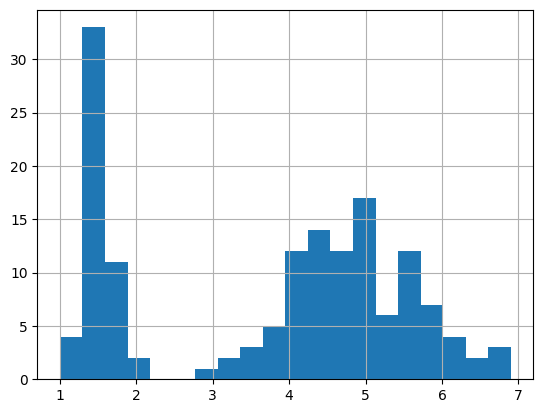

In [51]:
import matplotlib.pyplot as plt
df.petal_length.hist(bins=20)

Describe the distribution


* split in 2 groups
* each somewhat normally distributed
* group 1 narrow, group 2 wide

Which is more informative: the summary statistics or visualizations?

* viz

Visualize petal length and width with a "scatter_matrix"

array([[<Axes: xlabel='petal_length', ylabel='petal_length'>,
        <Axes: xlabel='petal_width', ylabel='petal_length'>],
       [<Axes: xlabel='petal_length', ylabel='petal_width'>,
        <Axes: xlabel='petal_width', ylabel='petal_width'>]], dtype=object)

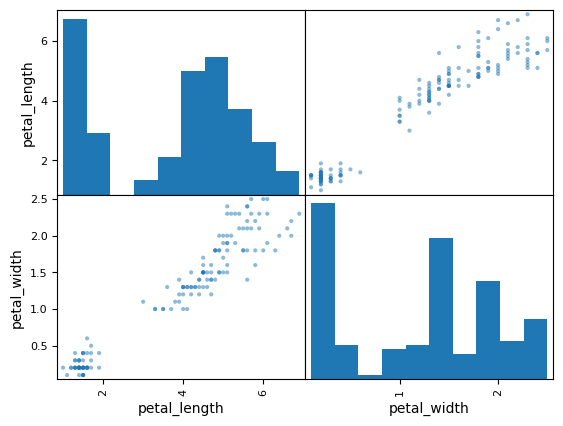

In [56]:
# see https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html
pd.plotting.scatter_matrix(
    df[["petal_length", "petal_width"]],
    #alpha=0.2,
)


Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [63]:
df["petal_area"] = df["petal_width"] * df["petal_length"]
df.head(), df.describe()

(   sepal_length  sepal_width  petal_length  petal_width      species  \
 0           5.1          3.5           1.4          0.2  Iris-setosa   
 1           4.9          3.0           1.4          0.2  Iris-setosa   
 2           4.7          3.2           1.3          0.2  Iris-setosa   
 3           4.6          3.1           1.5          0.2  Iris-setosa   
 4           5.0          3.6           1.4          0.2  Iris-setosa   
 
    sepal_size_sum  sepal_area  petal_area  
 0             8.6       17.85        0.28  
 1             7.9       14.70        0.28  
 2             7.9       15.04        0.26  
 3             7.7       14.26        0.30  
 4             8.6       18.00        0.28  ,
        sepal_length  sepal_width  petal_length  petal_width  sepal_size_sum  \
 count    150.000000   150.000000    150.000000   150.000000      150.000000   
 mean       5.843333     3.054000      3.758667     1.198667        8.897333   
 std        0.828066     0.433594      1.764420  

Create a new DataFrame with petal areas greater than $1cm^2$.

In [61]:
df_large_petals = df[df["petal_area"] > 1]
df_large_petals.describe()

,sepal_length,sepal_width,petal_length,petal_width,sepal_size_sum,sepal_area,petal_area
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,6.262000,2.872000,4.906000,1.676000,9.134000,18.105400,8.508300
std,0.662834,0.332751,0.825578,0.424769,0.891284,3.536697,3.328875
min,4.900000,2.000000,3.000000,1.000000,7.000000,10.000000,3.300000
25%,5.800000,2.700000,4.375000,1.300000,8.500000,15.732500,5.627500
50%,6.300000,2.900000,4.900000,1.600000,9.100000,17.920000,7.745000
75%,6.700000,3.025000,5.525000,2.000000,9.700000,20.770000,11.392500
max,7.900000,3.800000,6.900000,2.500000,11.700000,30.020000,15.870000


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [ ]:
data = {key:df for key,df in df.groupby('species')}
df_setosa, df_versicolor, df_virginica = data['Iris-setosa'], data['Iris-versicolor'], data['Iris-virginica']


sepal_length      21
sepal_width       14
petal_length      19
petal_width        9
species            1
sepal_size_sum    29
sepal_area        43
petal_area        36
dtype: int64